In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [3]:
train = pd.read_csv("https://raw.githubusercontent.com/valixonovai/ML/refs/heads/main/data_set/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/valixonovai/ML/refs/heads/main/data_set/test.csv")
sample_submission = pd.read_csv("https://raw.githubusercontent.com/valixonovai/ML/refs/heads/main/data_set/sample_submission.csv")

In [4]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [6]:
# Bo'sh qiymatlar (train)
train.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [7]:
# Bo'sh qiymatlar (test)
test.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
# Train dublikatlar soni
print("Train dublikatlar soni:", train.duplicated().sum())
print("--"*15)
print("Exited taqsimoti:", train['Exited'].value_counts(normalize=True))

print("--"*80)
print("Statistik tavsif: ")
train.describe()

Train dublikatlar soni: 0
------------------------------
Exited taqsimoti: Exited
0.0    0.801533
1.0    0.198467
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Statistik tavsif: 


,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,14999.000000,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


In [9]:
print(f"Age          min:{train['Age'].min()}     max: {train['Age'].max()}" )
print(f"CreditScore  min:{train['CreditScore'].min()}    max:{train['CreditScore'].max()}")
print(f"Balance      min:{train['Balance'].min()}      max:{train['Balance'].max()}")

Age          min:18.0     max: 72.0
CreditScore  min:431.0    max:850.0
Balance      min:0.0      max:187911.55


In [10]:
def clean_data(df):
    df = df.copy()
    df = df.drop(columns=['id', 'CustomerId', 'Surname'], errors='ignore')

    df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = df['Age'].median()
    df.loc[(df['CreditScore'] < 300) | (df['CreditScore'] > 900), 'CreditScore'] = df['CreditScore'].median()
    df.loc[df['Balance'] < 0, 'Balance'] = 0
    return df

train_clean = clean_data(train)
test_clean = clean_data(test)

print("Tozalangandan keyin train shape:", train_clean.shape)
print("Tozalangandan keyin test shape:", test_clean.shape)

Tozalangandan keyin train shape: (15000, 11)
Tozalangandan keyin test shape: (10000, 10)


In [11]:
def one_hot_encode(df, columns):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = encoder.fit_transform(df[columns])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(columns), index=df.index)
    return pd.concat([df.drop(columns=columns), encoded_df], axis=1)

In [12]:
train_clean = one_hot_encode(train_clean, ['Gender', 'Geography'])
test_clean = one_hot_encode(test_clean, ['Gender', 'Geography'])

In [13]:
test_clean

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,707.0,21.0,4.0,114513.66,2.0,1.0,0.0,176692.87,0.0,1.0,0.0,1.0,0.0
1,678.0,33.0,5.0,142510.50,1.0,0.0,0.0,52820.13,0.0,1.0,0.0,1.0,0.0
2,636.0,45.0,9.0,0.00,2.0,1.0,1.0,125062.02,0.0,1.0,0.0,0.0,1.0
3,697.0,46.0,8.0,0.00,2.0,1.0,0.0,131647.41,0.0,1.0,0.0,0.0,1.0
4,553.0,31.0,2.0,0.00,2.0,1.0,0.0,58814.41,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,583.0,46.0,4.0,0.00,2.0,1.0,1.0,175071.29,1.0,0.0,1.0,0.0,0.0
9996,513.0,42.0,4.0,148159.71,2.0,1.0,1.0,149740.22,0.0,1.0,1.0,0.0,0.0
9997,559.0,52.0,7.0,117561.49,3.0,1.0,0.0,163534.36,0.0,1.0,0.0,0.0,1.0
9998,811.0,30.0,7.0,0.00,2.0,1.0,1.0,104786.59,1.0,0.0,1.0,0.0,0.0


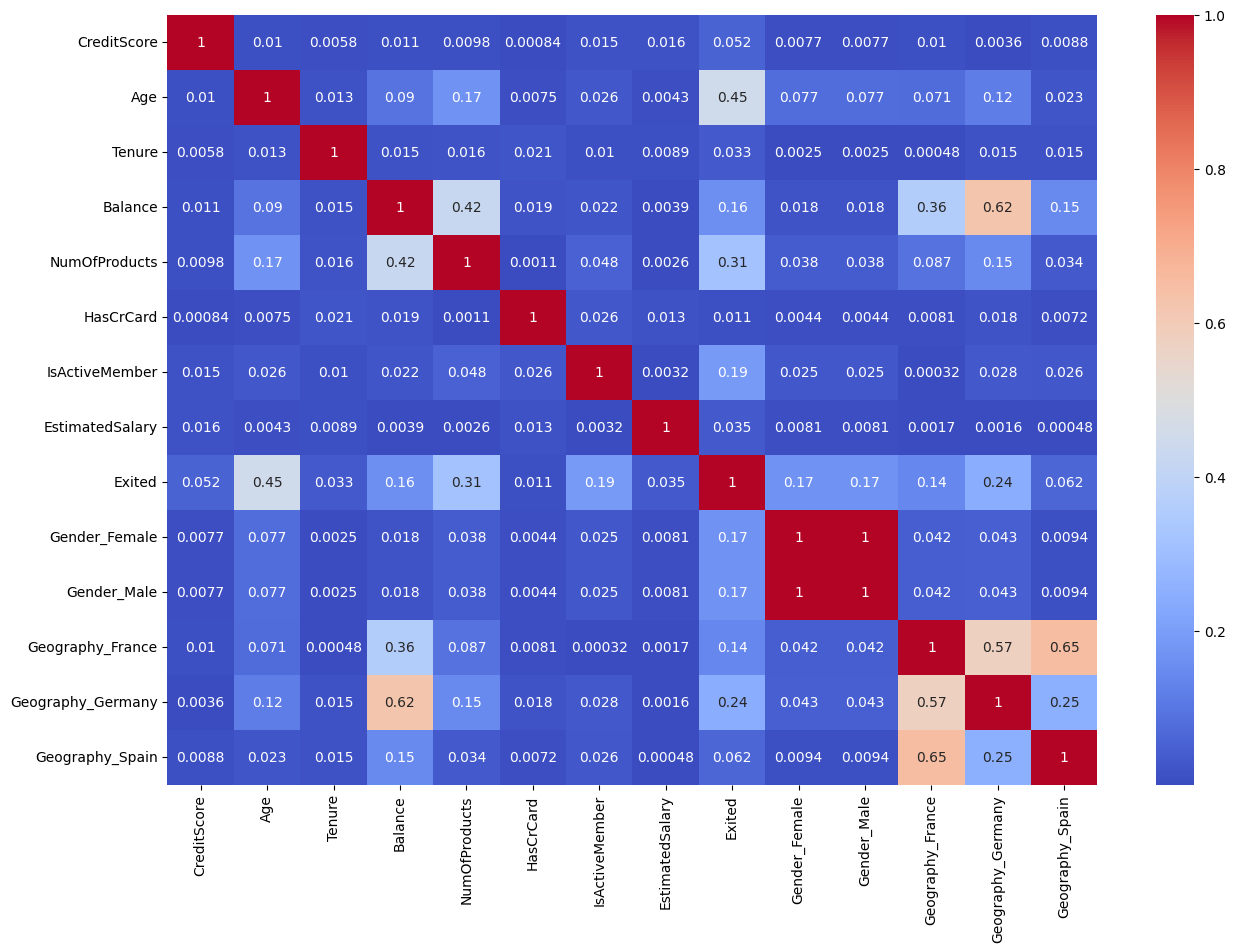

In [14]:
corr = train_clean.corr(numeric_only=True).abs()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [15]:
# X va y qiymatlarni ajratish
X_df = train_clean.drop(columns=["Exited"])
y = train_clean.Exited

# Scaler yaratish
scaler = StandardScaler()

X = scaler.fit_transform(X_df)
test = scaler.transform(test_clean)

X = pd.DataFrame(X, columns=X_df.columns)
test = pd.DataFrame(test, columns=test_clean.columns)

In [16]:
X.shape

(15000, 13)

In [17]:
test.shape

(10000, 13)

In [18]:
sample_submission.shape

(10000, 2)

In [19]:
sample_submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


Models

In [20]:
# 1. Train va Validation ga ajratish
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

r = []
for i in range(1, 100):
    rf = RandomForestClassifier(n_estimators=i, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    val_preds = rf.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, val_preds)
    r.append(score)

    print(f"n_estimators={i} uchun Validation ROC-AUC score: {score:.4f}")

# Eng yaxshi n_estimators bilan final model
best_n = r.index(max(r)) + 1
rf_model = RandomForestClassifier(n_estimators=best_n, random_state=42)
rf_model.fit(X, y)

test_preds = rf_model.predict_proba(test)[:, 1]
sample_submission['Exited'] = test_preds
sample_submission.to_csv('submission.csv', index=False)

n_estimators=1 uchun Validation ROC-AUC score: 0.7472
n_estimators=2 uchun Validation ROC-AUC score: 0.8022
n_estimators=3 uchun Validation ROC-AUC score: 0.8397
n_estimators=4 uchun Validation ROC-AUC score: 0.8610
n_estimators=5 uchun Validation ROC-AUC score: 0.8717
n_estimators=6 uchun Validation ROC-AUC score: 0.8728
n_estimators=7 uchun Validation ROC-AUC score: 0.8760
n_estimators=8 uchun Validation ROC-AUC score: 0.8818
n_estimators=9 uchun Validation ROC-AUC score: 0.8830
n_estimators=10 uchun Validation ROC-AUC score: 0.8863
n_estimators=11 uchun Validation ROC-AUC score: 0.8917
n_estimators=12 uchun Validation ROC-AUC score: 0.8952
n_estimators=13 uchun Validation ROC-AUC score: 0.8964
n_estimators=14 uchun Validation ROC-AUC score: 0.8983
n_estimators=15 uchun Validation ROC-AUC score: 0.8994
n_estimators=16 uchun Validation ROC-AUC score: 0.9001
n_estimators=17 uchun Validation ROC-AUC score: 0.8999
n_estimators=18 uchun Validation ROC-AUC score: 0.9008
n_estimators=19 uch

----------------------------------------------------------------------------------------------------
RandomForestClassifierning n_estimators uchun eng yaxshi qiymat 96 , aniqlik 0.9161534467163229
----------------------------------------------------------------------------------------------------


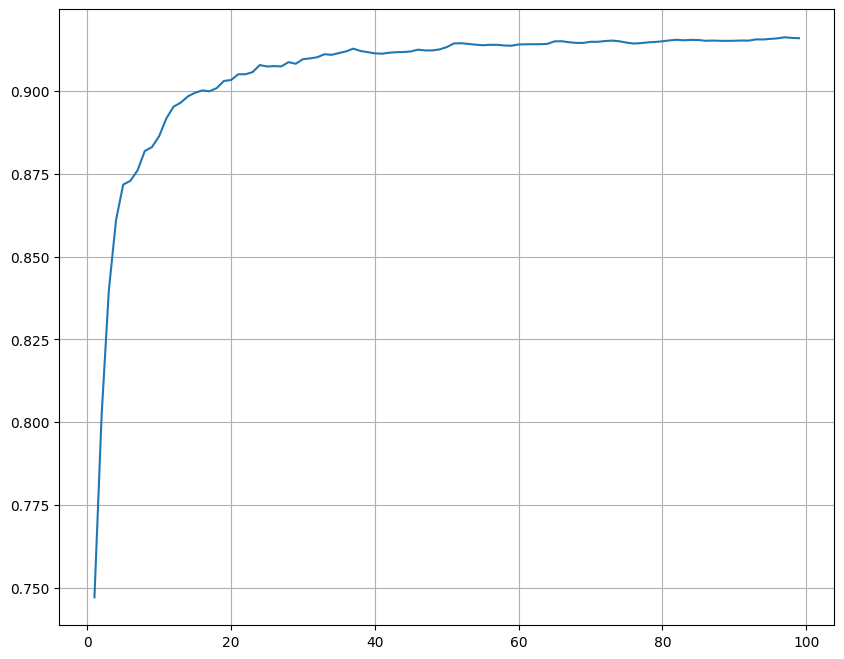

In [21]:
print("--"*50)
print(f"RandomForestClassifierning n_estimators uchun eng yaxshi qiymat {r.index(max(r))} , aniqlik {max(r)}")
print("--"*50)

plt.figure(figsize=(10,8))
plt.plot(range(1,100), r)
plt.grid()
plt.show()

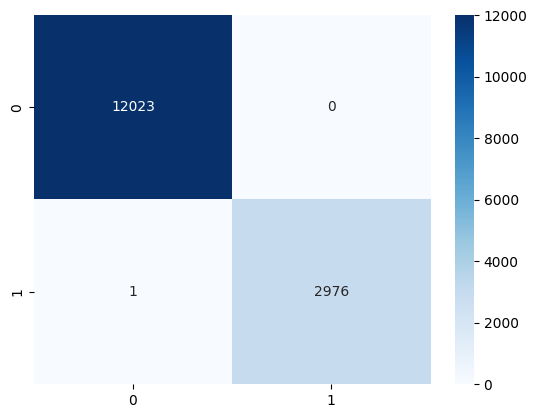

In [22]:
sns.heatmap(confusion_matrix(y, rf_model.predict(X)), fmt='d', cmap='Blues', annot=True)
plt.show()

In [23]:
r_xgb = []
for i in range(10, 201, 10):
    xgb = XGBClassifier(n_estimators=i, learning_rate=0.05, random_state=42, eval_metric='auc', n_jobs=-1)
    xgb.fit(X_train, y_train)

    val_preds = xgb.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, val_preds)
    r_xgb.append(score)
    print(f"XGBoost n_estimators={i} uchun Validation ROC-AUC score: {score:.4f}")

# Eng yaxshi n_estimators ni aniqlash va o'qitish
best_n_xgb = (r_xgb.index(max(r_xgb)) + 1) * 10
xgb_model = XGBClassifier(n_estimators=best_n_xgb, learning_rate=0.05, random_state=42, eval_metric='auc')
xgb_model.fit(X, y)

# Bashorat olish va saqlash
test_preds_xgb = xgb_model.predict_proba(test)[:, 1]
sample_submission['Exited'] = test_preds_xgb
sample_submission.to_csv('submission_xgb.csv', index=False)
print(f"\nEng yaxshi XGBoost ROC-AUC: {max(r_xgb):.4f} (n_estimators={best_n_xgb})")

XGBoost n_estimators=10 uchun Validation ROC-AUC score: 0.9289
XGBoost n_estimators=20 uchun Validation ROC-AUC score: 0.9298
XGBoost n_estimators=30 uchun Validation ROC-AUC score: 0.9311
XGBoost n_estimators=40 uchun Validation ROC-AUC score: 0.9306
XGBoost n_estimators=50 uchun Validation ROC-AUC score: 0.9301
XGBoost n_estimators=60 uchun Validation ROC-AUC score: 0.9304
XGBoost n_estimators=70 uchun Validation ROC-AUC score: 0.9301
XGBoost n_estimators=80 uchun Validation ROC-AUC score: 0.9299
XGBoost n_estimators=90 uchun Validation ROC-AUC score: 0.9300
XGBoost n_estimators=100 uchun Validation ROC-AUC score: 0.9296
XGBoost n_estimators=110 uchun Validation ROC-AUC score: 0.9294
XGBoost n_estimators=120 uchun Validation ROC-AUC score: 0.9294
XGBoost n_estimators=130 uchun Validation ROC-AUC score: 0.9293
XGBoost n_estimators=140 uchun Validation ROC-AUC score: 0.9290
XGBoost n_estimators=150 uchun Validation ROC-AUC score: 0.9290
XGBoost n_estimators=160 uchun Validation ROC-AUC

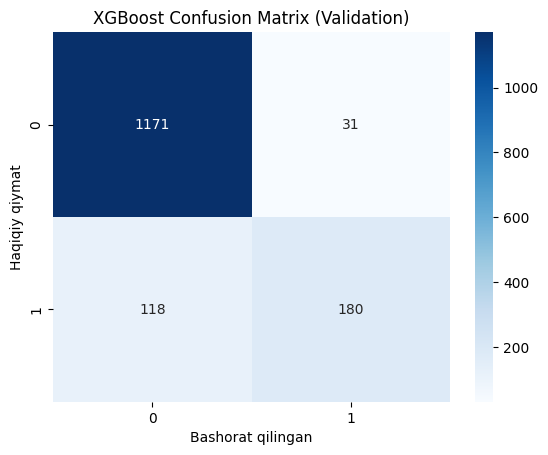

In [24]:
# XGBoost uchun confusion matrix
val_preds_proba = xgb_model.predict_proba(X_val)[:, 1]
val_preds_class = (val_preds_proba > 0.5).astype(int)

sns.heatmap(confusion_matrix(y_val, val_preds_class), annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix (Validation)")
plt.xlabel("Bashorat qilingan")
plt.ylabel("Haqiqiy qiymat")
plt.show()

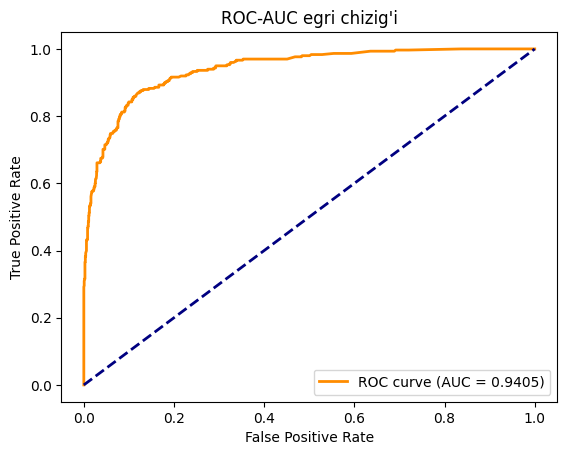

In [25]:
# XGBoost uchun ROC egri chizig'i
fpr, tpr, _ = roc_curve(y_val, val_preds_proba)
xgb_auc = roc_auc_score(y_val, val_preds_proba)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC-AUC egri chizig'i")
plt.legend(loc="lower right")
plt.show()

In [26]:
#LightGBM
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_auc = roc_auc_score(y_val, lgbm.predict_proba(X_val)[:, 1])
print(f"LightGBM Validation ROC-AUC score: {lgbm_auc:.4f}")

#CatBoost
cat = CatBoostClassifier(iterations=300, learning_rate=0.05, random_state=42, verbose=0)
cat.fit(X_train, y_train)
cat_auc = roc_auc_score(y_val, cat.predict_proba(X_val)[:, 1])
print(f"CatBoost Validation ROC-AUC score: {cat_auc:.4f}")

LightGBM Validation ROC-AUC score: 0.9300
CatBoost Validation ROC-AUC score: 0.9280


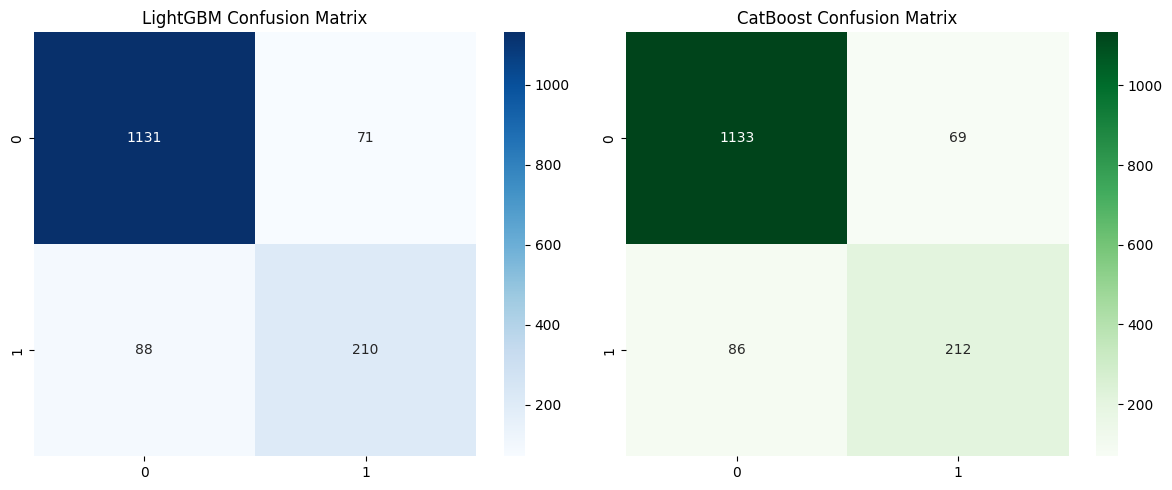

In [27]:
lgbm_val_proba = lgbm.predict_proba(X_val)[:, 1]
cat_val_proba = cat.predict_proba(X_val)[:, 1]

lgbm_val_pred = (lgbm_val_proba > 0.5).astype(int)
cat_val_pred = (cat_val_proba > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_val, lgbm_val_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("LightGBM Confusion Matrix")

sns.heatmap(confusion_matrix(y_val, cat_val_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("CatBoost Confusion Matrix")
plt.tight_layout()
plt.show()

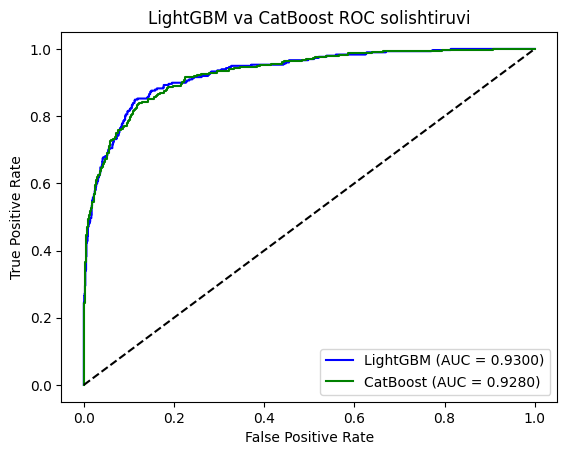

In [28]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgbm_val_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_val, cat_val_proba)

plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgbm_auc:.4f})', color='blue')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {cat_auc:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM va CatBoost ROC solishtiruvi')
plt.legend(loc='lower right')
plt.show()

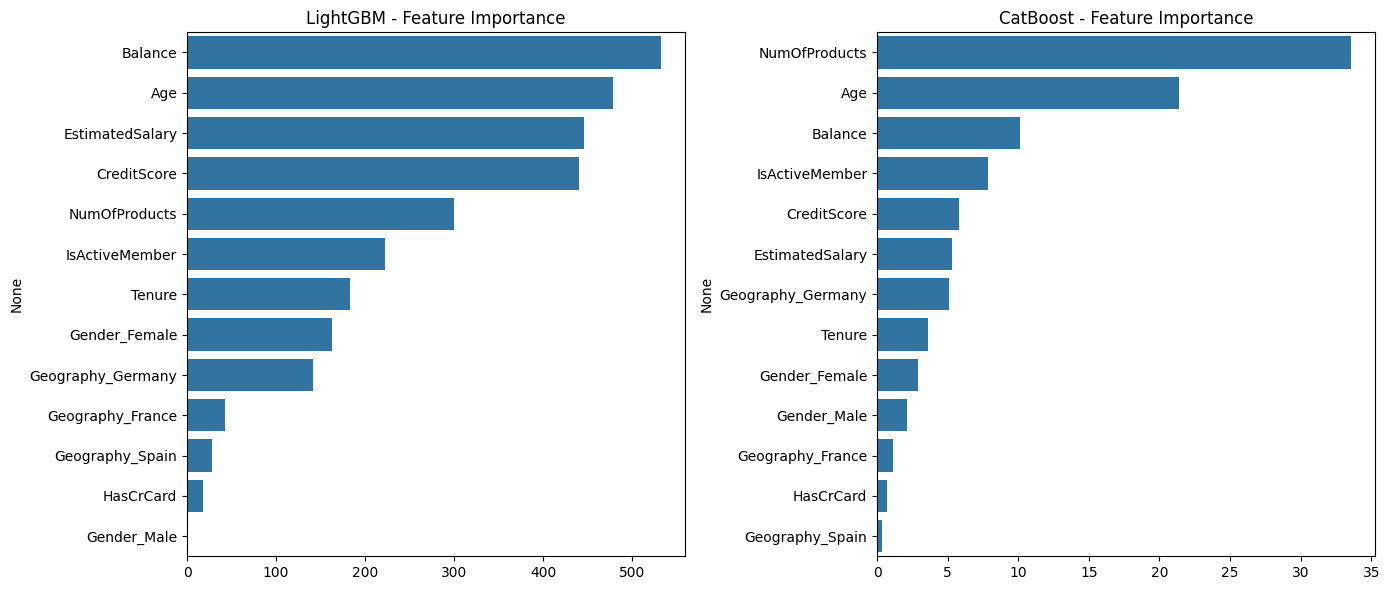

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lgb_imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=lgb_imp.values, y=lgb_imp.index, ax=axes[0])
axes[0].set_title("LightGBM - Feature Importance")

cat_imp = pd.Series(cat.get_feature_importance(), index=X.columns).sort_values(ascending=False)
sns.barplot(x=cat_imp.values, y=cat_imp.index, ax=axes[1])
axes[1].set_title("CatBoost - Feature Importance")

plt.tight_layout()
plt.show()

In [30]:
# To'liq ma'lumotda o'qitish
lgbm.fit(X, y)
cat.fit(X, y)

p_rf = rf_model.predict_proba(test)[:, 1]
p_xgb = xgb_model.predict_proba(test)[:, 1]
p_lgbm = lgbm.predict_proba(test)[:, 1]
p_cat = cat.predict_proba(test)[:, 1]

final_ensemble = (p_rf * 0.15) + (p_xgb * 0.35) + (p_lgbm * 0.25) + (p_cat * 0.25)

sample_submission['Exited'] = final_ensemble
sample_submission.to_csv('submission_ensemble.csv', index=False)

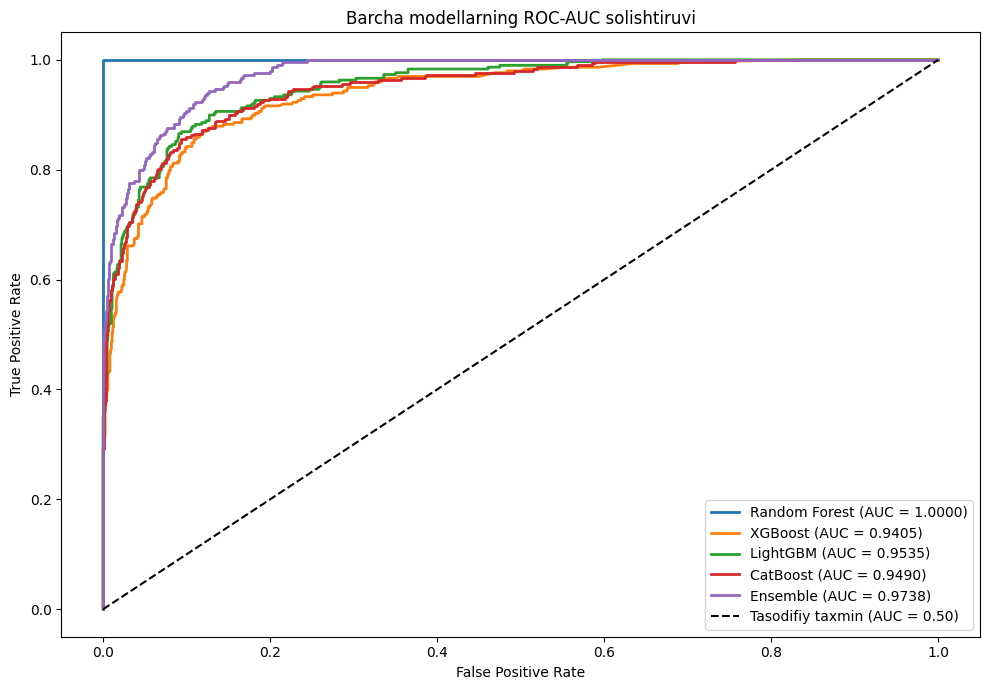

In [31]:
# Barcha modellarni validatsiyada solishtirish
val_probs = {
    'Random Forest': rf_model.predict_proba(X_val)[:, 1],
    'XGBoost': xgb_model.predict_proba(X_val)[:, 1],
    'LightGBM': lgbm.predict_proba(X_val)[:, 1],
    'CatBoost': cat.predict_proba(X_val)[:, 1],
}
val_probs['Ensemble'] = (val_probs['Random Forest'] * 0.15 + val_probs['XGBoost'] * 0.35 +
                          val_probs['LightGBM'] * 0.25 + val_probs['CatBoost'] * 0.25)

plt.figure(figsize=(10, 7))
for name, probs in val_probs.items():
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_val, probs):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Tasodifiy taxmin (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Barcha modellarning ROC-AUC solishtiruvi')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()